In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3964 - loss: 1.1572
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6131 - loss: 1.0142
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5521 - loss: 0.9129
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6912 - loss: 0.7190
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7881 - loss: 0.5747


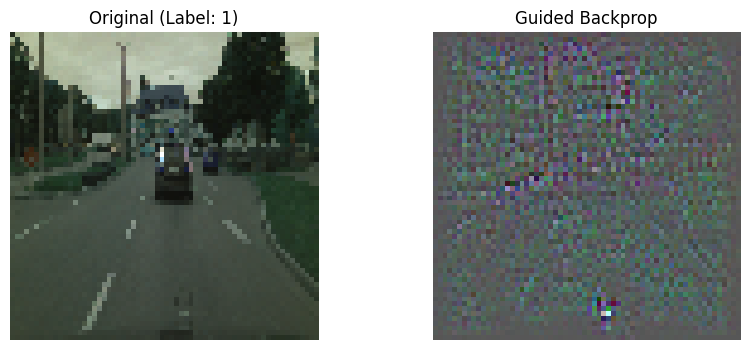

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# 🔹 1. LOAD DATASET (Cityscapes)
base_path = "/kaggle/input/datasets/xiaose/cityscapes/Cityspaces/images/val"

X = []
y = []

cities = os.listdir(base_path)

for label, city in enumerate(cities):
    folder = os.path.join(base_path, city)

    for file in os.listdir(folder):
        if file.endswith(".png"):
            img = cv2.imread(os.path.join(folder, file))
            img = cv2.resize(img, (64,64))

            X.append(img)
            y.append(label)

X = np.array(X) / 255.0
y = np.array(y)

# reduce size for speed
X = X[:300]
y = y[:300]

# 🔹 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 2. SIMPLE CNN
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(),

    Conv2D(32, (3,3), activation='relu'),
    Flatten(),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

# 🔹 3. PICK IMAGE
img = X_test[0:1]
label = y_test[0]

# 🔹 4. GUIDED RELU
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

# replace activations
for layer in model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

# 🔹 5. GRADIENTS
img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)

# 🔹 6. PROCESS IMAGE
guided_grads = grads[0].numpy()

guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min())

# 🔹 7. VISUALIZE
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title(f"Original (Label: {label})")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(guided_grads)
plt.title("Guided Backprop")
plt.axis('off')

plt.show()

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4859 - loss: 1.0851
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5412 - loss: 0.9898
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6141 - loss: 0.8748
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7083 - loss: 0.7903
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6693 - loss: 0.7870


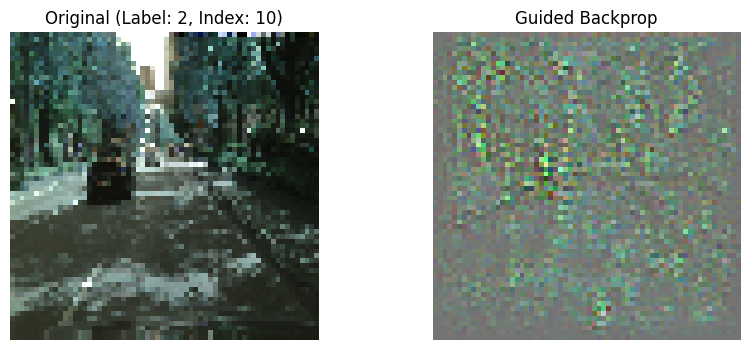

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# 🔹 LOAD DATASET
base_path = "/kaggle/input/datasets/xiaose/cityscapes/Cityspaces/images/val"

X = []
y = []

cities = os.listdir(base_path)

for label, city in enumerate(cities):
    folder = os.path.join(base_path, city)

    for file in os.listdir(folder):
        if file.endswith(".png"):
            img = cv2.imread(os.path.join(folder, file))
            img = cv2.resize(img, (64,64))

            X.append(img)
            y.append(label)

X = np.array(X) / 255.0
y = np.array(y)

# reduce size
X = X[:300]
y = y[:300]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 MODEL
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(),

    Conv2D(32, (3,3), activation='relu'),
    Flatten(),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=5, batch_size=32)

# 🔥 OPTION 1: CHANGE IMAGE HERE
index = 10   # 👉 change this value (0,5,20,50...)

img = X_test[index:index+1]
label = y_test[index]

# 🔹 GUIDED RELU
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

# replace relu
for layer in model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

# 🔹 GRADIENTS
img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)

# 🔹 PROCESS
guided_grads = grads[0].numpy()
guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min())

# 🔹 VISUALIZE
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title(f"Original (Label: {label}, Index: {index})")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(guided_grads)
plt.title("Guided Backprop")
plt.axis('off')

plt.show()

OBSERVATION 

* Guided backpropagation highlights the important pixels used by the model for prediction.
* Bright regions in the output indicate areas that strongly influence the classification.
* Different images produce different highlighted regions based on their features.
* It helps in understanding how the model focuses on specific parts of the image.